# OncoBridge — Data Processing Notebook v4
## GDSC2 · Raw SMILES · Three Evaluation Splits · Robust Methylation Fix

### What's new in v4:
| Change | Description |
|--------|-------------|
| **GDSC2-only** | `USE_GDSC1 = False` — fair comparison vs literature |
| **Raw SMILES** | PubChem fetch → canonical SMILES saved as CSV (no Morgan FP) |
| **Methylation fix** | Gene column preserved; TSS→gene→TCGA overlap correct; 0.5 neutral fill |
| **Three splits** | Warm-start (80/10/10), Cell-Cold-Start (20% cells held out), Drug-Cold-Start (15% drugs held out) |
| **LN(IC50)** | log2 × ln(2) conversion |


In [1]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 1 — INSTALLS  (run once; Kaggle caches pip packages)
# ═══════════════════════════════════════════════════════════════════════
import subprocess, sys

def pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

pip('pubchempy', 'pyarrow', 'fastparquet')
print('✓ pubchempy  ✓ pyarrow  ✓ fastparquet installed.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.4 MB/s eta 0:00:00
✓ pubchempy  ✓ pyarrow  ✓ fastparquet installed.


In [2]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 2 — IMPORTS & HELPERS
# ═══════════════════════════════════════════════════════════════════════
import os, re, gc, json, time, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder

import pubchempy as pcp

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

def section(t):
    print('\n' + '═'*70)
    print(f'  {t}')
    print('═'*70)

def mem_usage(df, name):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  [{name}] RAM: {mb:.1f} MB | shape: {df.shape}')

print('Imports OK.')


Imports OK.


In [3]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 3 — CONFIG  ← edit paths and flags here
#  NOTE: USE_GDSC1 is intentionally False — we use GDSC2 only.
#  Variable names still reference "gdsc1" in paths because that's how
#  the Kaggle dataset is named; the data itself is GDSC2.
# ═══════════════════════════════════════════════════════════════════════

CFG = dict(
    # ── Dataset toggle ──────────────────────────────────────────────────
    USE_GDSC1 = False,   # False = GDSC2 only (fair comparison vs literature)

    # ── IC50 scale ──────────────────────────────────────────────────────
    IC50_SCALE = 'ln',   # 'ln' = multiply log2 by ln(2) — correct for RMSE

    # ── Drug / cell line filters ────────────────────────────────────────
    MIN_SAMPLES_PER_DRUG     = 100,
    MIN_SAMPLES_PER_CELLLINE = 10,

    # ── Split fractions ──────────────────────────────────────────────────
    WARM_VAL_FRAC      = 0.10,    # warm-start: 80/10/10
    WARM_TEST_FRAC     = 0.10,
    CELL_COLD_FRAC     = 0.20,    # cell-cold-start: 20% cell lines held out
    DRUG_COLD_FRAC     = 0.15,    # drug-cold-start: 15% drugs held out
    SEED               = 42,

    # ── Gene dims — must match TCGA Phase 1 training ─────────────────────
    N_MRNA  = 8011,
    N_CNV   = 3500,
    N_MUT   = 2500,
    N_METH  = 6000,

    # ── Paths ─────────────────────────────────────────────────────────────
    BASE         = '/kaggle/input/datasets/proutkarshtiwari/drug-cell-line-data-phase-2',
    SANGER_CSV   = 'sanger-dose-response.csv',
    MODEL_CSV    = 'Model.csv',
    MRNA_CSV     = 'OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv',
    CNV_CSV      = 'OmicsCNGeneWGS.csv',
    MUT_CSV      = 'OmicsSomaticMutationsMatrixDamaging.csv',
    METH_CSV     = 'CCLE_RRBS_TSS_1kb_20180614.txt',
    GENE_JSON    = '/kaggle/input/datasets/proutkarshtiwari/drug-cell-line-data-phase-2/selected_genes.json',
    SMILES_CACHE = '/kaggle/working/drug_smiles_cache.csv',
    OUT_DIR      = '/kaggle/working/',
)

DATASETS = ['GDSC1', 'GDSC2'] if CFG['USE_GDSC1'] else ['GDSC2']
print(f'USE_GDSC1     = {CFG["USE_GDSC1"]}  →  Datasets filtered: {DATASETS}')
print(f'IC50_SCALE    = {CFG["IC50_SCALE"]}')
print(f'Cell-cold frac: {CFG["CELL_COLD_FRAC"]*100:.0f}%  |  Drug-cold frac: {CFG["DRUG_COLD_FRAC"]*100:.0f}%')
print(f'Warm split: {int((1-CFG["WARM_VAL_FRAC"]-CFG["WARM_TEST_FRAC"])*100)}/{int(CFG["WARM_VAL_FRAC"]*100)}/{int(CFG["WARM_TEST_FRAC"]*100)} (train/val/test)')


USE_GDSC1     = False  →  Datasets filtered: ['GDSC2']
IC50_SCALE    = ln
Cell-cold frac: 20%  |  Drug-cold frac: 15%
Warm split: 80/10/10 (train/val/test)


In [4]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 4 — LOAD TCGA GENE LISTS (Phase 1 anchor)
#  These are the EXACT gene lists the backbone was pre-trained on.
#  We MUST align CCLE features to this space — no extra features allowed.
# ═══════════════════════════════════════════════════════════════════════
section('4. TCGA GENE LISTS')

with open(CFG['GENE_JSON']) as f:
    gene_names = json.load(f)

GENES = {
    'mrna': gene_names['mrna'],   # 8011 genes
    'cnv':  gene_names['cnv'],    # 3500 genes
    'mut':  gene_names['mut'],    # 2500 genes
    'meth': gene_names['meth'],   # 6000 genes — methylation beta values
}

print('Gene counts from Phase 1 training (TCGA):')
for k, v in GENES.items():
    print(f'  {k:>4}: {len(v):>6,} genes')
print(f'  Total features: {sum(len(v) for v in GENES.values()):,}')



══════════════════════════════════════════════════════════════════════
  4. TCGA GENE LISTS
══════════════════════════════════════════════════════════════════════
Gene counts from Phase 1 training (TCGA):
  mrna:  8,011 genes
   cnv:  3,500 genes
   mut:  2,500 genes
  meth:  6,000 genes
  Total features: 20,011



══════════════════════════════════════════════════════════════════════
  5. SANGER IC50 LABELS
══════════════════════════════════════════════════════════════════════
Raw shape: (387626, 20)
Datasets in file: ['GDSC1' 'GDSC2']
After dataset filter (['GDSC2']): 118,908 rows
Converted log2(IC50) → ln(IC50) [×0.6931]
IC50 stats: mean=-0.298  std=2.550  range=[-8.63, 4.60]
After deduplication: 23,739 rows
After drug filter (≥100 samples): 21,337 rows | 66 drugs
After cell line filter (≥10 drugs): 20,697 rows

Final: 20,697 IC50 pairs | 66 drugs | 695 cell lines
Elapsed: 2.7s


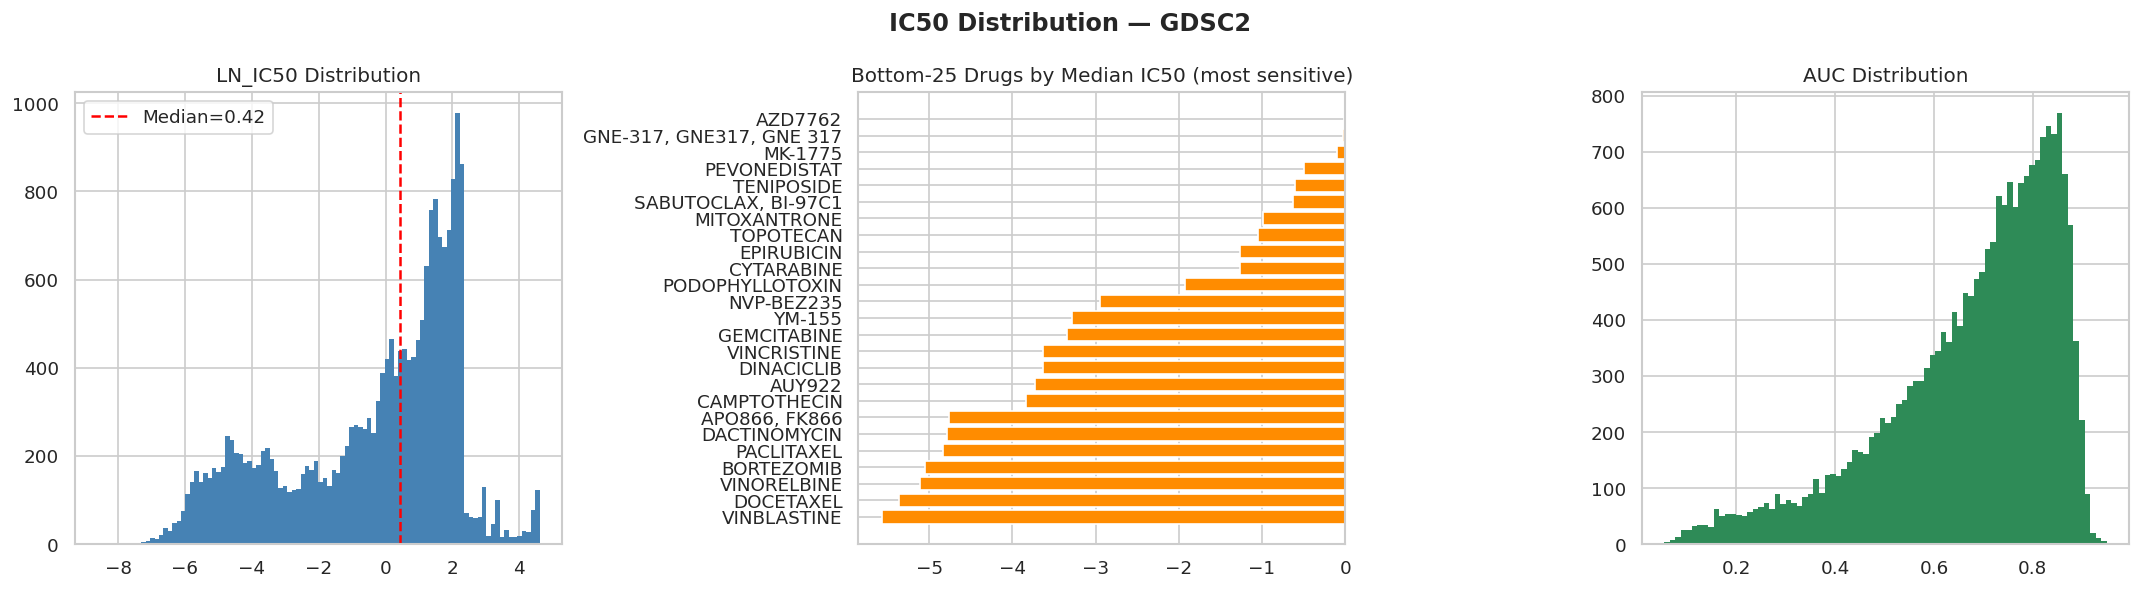

In [5]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 5 — SANGER IC50 LABELS
#  Source: sanger-dose-response.csv
#  We convert log2(IC50) → ln(IC50) by multiplying by ln(2) ≈ 0.6931.
#  This ensures RMSE is comparable to literature values reported in ln space.
# ═══════════════════════════════════════════════════════════════════════
section('5. SANGER IC50 LABELS')

t0 = time.time()
raw = pd.read_csv(f"{CFG['BASE']}/{CFG['SANGER_CSV']}", low_memory=False)
print(f'Raw shape: {raw.shape}')
print(f'Datasets in file: {raw["DATASET"].unique()}')

# ── Filter to GDSC2 only ─────────────────────────────────────────────────
ic50 = raw[raw['DATASET'].isin(DATASETS)].copy()
print(f'After dataset filter ({DATASETS}): {len(ic50):,} rows')

# ── Drop missing IC50 ───────────────────────────────────────────────────
ic50 = ic50.dropna(subset=['log2.ic50'])

# ── Convert log2(IC50) → ln(IC50) ──────────────────────────────────────
LN2 = np.log(2)   # ≈ 0.6931
ic50['ic50_value'] = ic50['log2.ic50'] * LN2
print(f'Converted log2(IC50) → ln(IC50) [×{LN2:.4f}]')
print(f'IC50 stats: mean={ic50["ic50_value"].mean():.3f}  '
      f'std={ic50["ic50_value"].std():.3f}  '
      f'range=[{ic50["ic50_value"].min():.2f}, {ic50["ic50_value"].max():.2f}]')

# ── Deduplicate (for GDSC2-only this is a no-op, but kept for safety) ────
ic50 = ic50.drop_duplicates(subset=['COSMIC_ID', 'DRUG_NAME'], keep='first')
print(f'After deduplication: {len(ic50):,} rows')

# ── Drug coverage filter ─────────────────────────────────────────────────
drug_counts = ic50['DRUG_NAME'].value_counts()
valid_drugs = drug_counts[drug_counts >= CFG['MIN_SAMPLES_PER_DRUG']].index
ic50 = ic50[ic50['DRUG_NAME'].isin(valid_drugs)]
print(f'After drug filter (≥{CFG["MIN_SAMPLES_PER_DRUG"]} samples): '
      f'{len(ic50):,} rows | {ic50["DRUG_NAME"].nunique()} drugs')

# ── Cell line filter ─────────────────────────────────────────────────────
cl_counts = ic50.groupby('COSMIC_ID').size()
valid_cls  = cl_counts[cl_counts >= CFG['MIN_SAMPLES_PER_CELLLINE']].index
ic50 = ic50[ic50['COSMIC_ID'].isin(valid_cls)]
print(f'After cell line filter (≥{CFG["MIN_SAMPLES_PER_CELLLINE"]} drugs): '
      f'{len(ic50):,} rows')

# ── Finalise columns ─────────────────────────────────────────────────────
ic50 = ic50[['COSMIC_ID','DRUG_NAME','DATASET','ic50_value',
             'AUC_PUBLISHED','Z_SCORE_PUBLISHED']].copy()
ic50 = ic50.rename(columns={'AUC_PUBLISHED':'AUC','Z_SCORE_PUBLISHED':'Z_SCORE'})
ic50['COSMIC_ID'] = ic50['COSMIC_ID'].astype(int)

DRUG_NAMES = sorted(ic50['DRUG_NAME'].unique())
print(f'\nFinal: {len(ic50):,} IC50 pairs | {ic50["DRUG_NAME"].nunique()} drugs | '
      f'{ic50["COSMIC_ID"].nunique()} cell lines')
print(f'Elapsed: {time.time()-t0:.1f}s')
del raw; gc.collect()

# ── EDA ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'IC50 Distribution — GDSC2', fontweight='bold')
axes[0].hist(ic50['ic50_value'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('LN_IC50 Distribution')
axes[0].axvline(ic50['ic50_value'].median(), color='red', ls='--',
                label=f'Median={ic50["ic50_value"].median():.2f}')
axes[0].legend()
drug_med = ic50.groupby('DRUG_NAME')['ic50_value'].median().sort_values().head(25)
axes[1].barh(drug_med.index, drug_med.values, color='darkorange')
axes[1].set_title('Bottom-25 Drugs by Median IC50 (most sensitive)')
axes[2].hist(ic50['AUC'].dropna(), bins=80, color='seagreen', edgecolor='none')
axes[2].set_title('AUC Distribution')
plt.tight_layout(); plt.show()


In [6]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 6 — FETCH & SAVE RAW CANONICAL SMILES FROM PUBCHEM
#
#  KEY CHANGE from v3: We NO LONGER compute Morgan Fingerprints here.
#  Instead we save raw canonical SMILES strings to CSV.
#  ChemBERTa (Notebook 2) will tokenize these on-the-fly.
#
#  Rationale: ChemBERTa was pre-trained on SMILES strings, not binary FPs.
#  Feeding raw SMILES preserves the full chemical language context,
#  enabling better transfer learning from ChemBERTa's pre-training.
# ═══════════════════════════════════════════════════════════════════════
section('6. FETCH RAW CANONICAL SMILES FROM PUBCHEM')

def clean_name(name):
    """Extract primary drug name from GDSC alias strings like 'Drug A; Drug B'."""
    primary = name.split(';')[0].strip()
    primary = re.sub(r'\s*\(.*?\)', '', primary).strip()
    return primary

def fetch_smiles_pubchem(name, timeout=15):
    """Query PubChem by name, return canonical SMILES or None."""
    try:
        res = pcp.get_compounds(name, 'name', timeout=timeout)
        if res:
            smiles = res[0].canonical_smiles or res[0].isomeric_smiles
            if smiles:
                return smiles
    except Exception:
        pass
    return None

def load_or_fetch_smiles_cache(drug_names, cache_path, sleep_sec=0.4):
    """
    Load SMILES from disk cache if available, otherwise fetch from PubChem.
    Cache is a simple CSV: drug_name, canonical_smiles.
    Returns dict: {drug_name: smiles_string_or_None}
    """
    cache_path = Path(cache_path)
    cache = {}

    if cache_path.exists():
        df_c = pd.read_csv(cache_path)
        cache = {
            r['drug_name']: (None if pd.isna(r['canonical_smiles']) else r['canonical_smiles'])
            for _, r in df_c.iterrows()
        }
        print(f'  Loaded {len(cache)} cached SMILES entries from {cache_path.name}')

    missing = [d for d in drug_names if d not in cache]
    print(f'  Drugs to fetch from PubChem: {len(missing)}')

    for i, name in enumerate(missing):
        smiles = fetch_smiles_pubchem(clean_name(name))

        if smiles is None and ';' in name:
            for alias in name.split(';'):
                smiles = fetch_smiles_pubchem(alias.strip())
                if smiles:
                    break

        cache[name] = smiles
        status = 'OK ✓' if smiles else 'MISSING ✗'

        if (i + 1) % 10 == 0 or i == len(missing) - 1:
            print(f'  [{i+1:>3}/{len(missing)}] {name[:55]:<55}  {status}')
            time.sleep(sleep_sec)

    pd.DataFrame(
        [(k, v) for k, v in cache.items()],
        columns=['drug_name', 'canonical_smiles']
    ).to_csv(cache_path, index=False)
    print(f'  Cache saved → {cache_path}')

    return cache


print(f'Fetching canonical SMILES for {len(DRUG_NAMES)} GDSC2 drugs...')
print('This will be cached to disk — only slow on first run.\n')
smiles_map = load_or_fetch_smiles_cache(DRUG_NAMES, CFG['SMILES_CACHE'])

n_ok   = sum(1 for v in smiles_map.values() if v is not None)
n_miss = len(smiles_map) - n_ok
print(f'\nSMILES coverage:')
print(f'  Found:   {n_ok}/{len(smiles_map)} drugs ({n_ok/len(smiles_map)*100:.1f}%)')
print(f'  Missing: {n_miss} drugs (will be excluded from training)')

if n_miss > 0:
    missing_list = [d for d, s in smiles_map.items() if s is None]
    print(f'  Missing drug names: {missing_list[:10]}')

VALID_DRUG_NAMES = sorted([d for d, s in smiles_map.items() if s is not None])
before = len(ic50)
ic50 = ic50[ic50['DRUG_NAME'].isin(VALID_DRUG_NAMES)].copy()
print(f'\nIC50 rows after SMILES filter: {before:,} → {len(ic50):,}')
print(f'Final drug count: {len(VALID_DRUG_NAMES)}')

smiles_df = pd.DataFrame(
    [(d, smiles_map[d]) for d in VALID_DRUG_NAMES],
    columns=['drug_name', 'canonical_smiles']
)
smiles_df.to_csv(f"{CFG['OUT_DIR']}/drug_canonical_smiles.csv", index=False)
print(f'\nSaved: drug_canonical_smiles.csv  (shape: {smiles_df.shape})')
print('Sample SMILES:')
print(smiles_df.head(5).to_string(index=False))



══════════════════════════════════════════════════════════════════════
  6. FETCH RAW CANONICAL SMILES FROM PUBCHEM
══════════════════════════════════════════════════════════════════════
Fetching canonical SMILES for 66 GDSC2 drugs...
This will be cached to disk — only slow on first run.

  Drugs to fetch from PubChem: 66
  [ 10/66] AZD6738                                                  OK ✓
  [ 20/66] CISPLATIN                                                OK ✓
  [ 30/66] GDC-0941                                                 OK ✓
  [ 40/66] NAVITOCLAX                                               OK ✓
  [ 50/66] SABUTOCLAX, BI-97C1                                      MISSING ✗
  [ 60/66] VINCRISTINE                                              OK ✓
  [ 66/66] YM-155                                                   OK ✓
  Cache saved → /kaggle/working/drug_smiles_cache.csv

SMILES coverage:
  Found:   58/66 drugs (87.9%)
  Missing: 8 drugs (will be excluded from training)
  Mi

In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 7 — MODEL.CSV — CELL LINE METADATA & ID MAPPING
# ═══════════════════════════════════════════════════════════════════════
section('7. MODEL.CSV — ID MAPPING')

model_df = pd.read_csv(f"{CFG['BASE']}/{CFG['MODEL_CSV']}")
model_df = model_df[['ModelID','CellLineName','COSMICID',
                      'OncotreePrimaryDisease','OncotreeLineage',
                      'OncotreeSubtype','CCLEName']].copy()
model_df = model_df.dropna(subset=['COSMICID'])
model_df['COSMICID'] = model_df['COSMICID'].astype(int)
print(f'Model.csv: {len(model_df)} rows | {model_df["COSMICID"].nunique()} unique COSMICs')

ic50 = ic50.merge(model_df, left_on='COSMIC_ID', right_on='COSMICID', how='inner')
print(f'After join: {len(ic50):,} IC50 pairs')
print(f'Unique cell lines: {ic50["ModelID"].nunique()}')
print(f'Unique cancer types: {ic50["OncotreePrimaryDisease"].nunique()}')

drug2idx  = {d: i for i, d in enumerate(VALID_DRUG_NAMES)}
id_to_drug = {i: d for d, i in drug2idx.items()}
ic50['drug_idx'] = ic50['DRUG_NAME'].map(drug2idx)

valid_model_ids = set(ic50['ModelID'].unique())
print(f'Valid ModelIDs: {len(valid_model_ids)}')



══════════════════════════════════════════════════════════════════════
  7. MODEL.CSV — ID MAPPING
══════════════════════════════════════════════════════════════════════
Model.csv: 977 rows | 977 unique COSMICs
After join: 17,313 IC50 pairs
Unique cell lines: 676
Unique cancer types: 65
Valid ModelIDs: 676


In [8]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 8 — CCLE mRNA EXPRESSION
# ═══════════════════════════════════════════════════════════════════════
section('8. CCLE mRNA')

mrna_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['MRNA_CSV']}", index_col=0, low_memory=False)
print(f'Raw shape: {mrna_raw.shape}')

if 'IsDefaultEntryForModel' in mrna_raw.columns:
    mrna_raw = mrna_raw[mrna_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    mrna_raw = mrna_raw.set_index('ModelID')
    mrna_raw = mrna_raw.drop(columns=['SequencingID','ModelConditionID',
                                       'IsDefaultEntryForMC','IsDefaultEntryForModel'],
                               errors='ignore')

mrna_raw.columns = [str(c).split(' (')[0].strip() for c in mrna_raw.columns]
mrna_raw = mrna_raw.loc[:, ~mrna_raw.columns.duplicated(keep='first')]
mrna_raw = mrna_raw[mrna_raw.index.isin(valid_model_ids)]

overlap_m = set(mrna_raw.columns) & set(GENES['mrna'])
print(f'mRNA overlap with TCGA genes: {len(overlap_m)}/{len(GENES["mrna"])}')

mrna_df = mrna_raw.reindex(columns=GENES['mrna'], fill_value=0.0).fillna(0.0).astype(np.float32)
print(f'Final mRNA: {mrna_df.shape}')
valid_model_ids_mrna = set(mrna_df.index)
del mrna_raw; gc.collect()
mem_usage(mrna_df, 'mRNA')



══════════════════════════════════════════════════════════════════════
  8. CCLE mRNA
══════════════════════════════════════════════════════════════════════
Raw shape: (1775, 19220)
mRNA overlap with TCGA genes: 7374/8011
Final mRNA: (524, 8011)
  [mRNA] RAM: 16.8 MB | shape: (524, 8011)


In [9]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 9 — CCLE CNV
# ═══════════════════════════════════════════════════════════════════════
section('9. CCLE CNV')

cnv_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['CNV_CSV']}", index_col=0, low_memory=False)
if 'IsDefaultEntryForModel' in cnv_raw.columns:
    cnv_raw = cnv_raw[cnv_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    cnv_raw = cnv_raw.set_index('ModelID')
    cnv_raw = cnv_raw.drop(columns=['SequencingID','ModelConditionID',
                                     'IsDefaultEntryForMC','IsDefaultEntryForModel'],
                            errors='ignore')

cnv_raw.columns = [str(c).split(' (')[0].strip() for c in cnv_raw.columns]
cnv_raw = cnv_raw.loc[:, ~cnv_raw.columns.duplicated(keep='first')]
cnv_raw = cnv_raw[cnv_raw.index.isin(valid_model_ids)]
cnv_raw = cnv_raw.fillna(2.0).clip(lower=0.01)
cnv_raw = np.log2(cnv_raw / 2.0).astype(np.float32)

overlap_c = set(cnv_raw.columns) & set(GENES['cnv'])
print(f'CNV overlap with TCGA genes: {len(overlap_c)}/{len(GENES["cnv"])}')

cnv_df = cnv_raw.reindex(columns=GENES['cnv'], fill_value=0.0).astype(np.float32)
print(f'Final CNV: {cnv_df.shape}')
valid_model_ids_cnv = set(cnv_df.index)
del cnv_raw; gc.collect()
mem_usage(cnv_df, 'CNV')



══════════════════════════════════════════════════════════════════════
  9. CCLE CNV
══════════════════════════════════════════════════════════════════════
CNV overlap with TCGA genes: 3232/3500
Final CNV: (382, 3500)
  [CNV] RAM: 5.4 MB | shape: (382, 3500)


In [10]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 10 — CCLE MUTATION
# ═══════════════════════════════════════════════════════════════════════
section('10. CCLE MUTATION')

mut_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['MUT_CSV']}", index_col=0, low_memory=False)
if 'IsDefaultEntryForModel' in mut_raw.columns:
    mut_raw = mut_raw[mut_raw['IsDefaultEntryForModel'] == 'Yes'].copy()
    mut_raw = mut_raw.set_index('ModelID')
    mut_raw = mut_raw.drop(columns=['SequencingID','ModelConditionID',
                                     'IsDefaultEntryForMC','IsDefaultEntryForModel'],
                            errors='ignore')

mut_raw.columns = [str(c).split(' (')[0].strip() for c in mut_raw.columns]
mut_raw = mut_raw.loc[:, ~mut_raw.columns.duplicated(keep='first')]
mut_raw = mut_raw[mut_raw.index.isin(valid_model_ids)]
mut_raw = mut_raw.fillna(0).clip(0, 1).round(0).astype(np.int8)

overlap_u = set(mut_raw.columns) & set(GENES['mut'])
sparsity  = (mut_raw == 0).values.mean()
print(f'Mutation overlap with TCGA genes: {len(overlap_u)}/{len(GENES["mut"])}')
print(f'Sparsity (wildtype fraction): {sparsity*100:.1f}%')

mut_df = mut_raw.reindex(columns=GENES['mut'], fill_value=0).astype(np.float32)
print(f'Final Mutation: {mut_df.shape}')
valid_model_ids_mut = set(mut_df.index)
del mut_raw; gc.collect()
mem_usage(mut_df, 'Mutation')



══════════════════════════════════════════════════════════════════════
  10. CCLE MUTATION
══════════════════════════════════════════════════════════════════════
Mutation overlap with TCGA genes: 2380/2500
Sparsity (wildtype fraction): 99.6%
Final Mutation: (667, 2500)
  [Mutation] RAM: 6.7 MB | shape: (667, 2500)



══════════════════════════════════════════════════════════════════════
  11. CCLE METHYLATION (RRBS) — ROBUST GENE OVERLAP
══════════════════════════════════════════════════════════════════════
Loading CCLE_RRBS_TSS_1kb_20180614.txt...
Raw shape: (20192, 850)
Column names [0:8]: ['TSS_id', 'gene', 'chr', 'fpos', 'tpos', 'strand', 'avg_coverage', 'DMS53_LUNG']
Gene column found. Sample values: ['LOC100288069' 'LINC01128' 'LINC01128' 'LOC100130417' 'SAMD11']

After dropping metadata: (20192, 844)
TSS aggregation: 20,192 TSS → 16,494 unique genes
After transpose: (844, 16494)
Mapped CCLEName → ModelID: 844 → 839 cell lines
Filtered to cell lines with GDSC2 IC50: 839 → 411
Missing values: 270,937 → 0

Gene space alignment (Methylation):
  TCGA selected genes:   6,000
  CCLE RRBS genes:       16,494
  Overlap:               3,205  (53.4%)
  Missing in CCLE→0.5:   2,795

Final Methylation shape: (411, 6000)


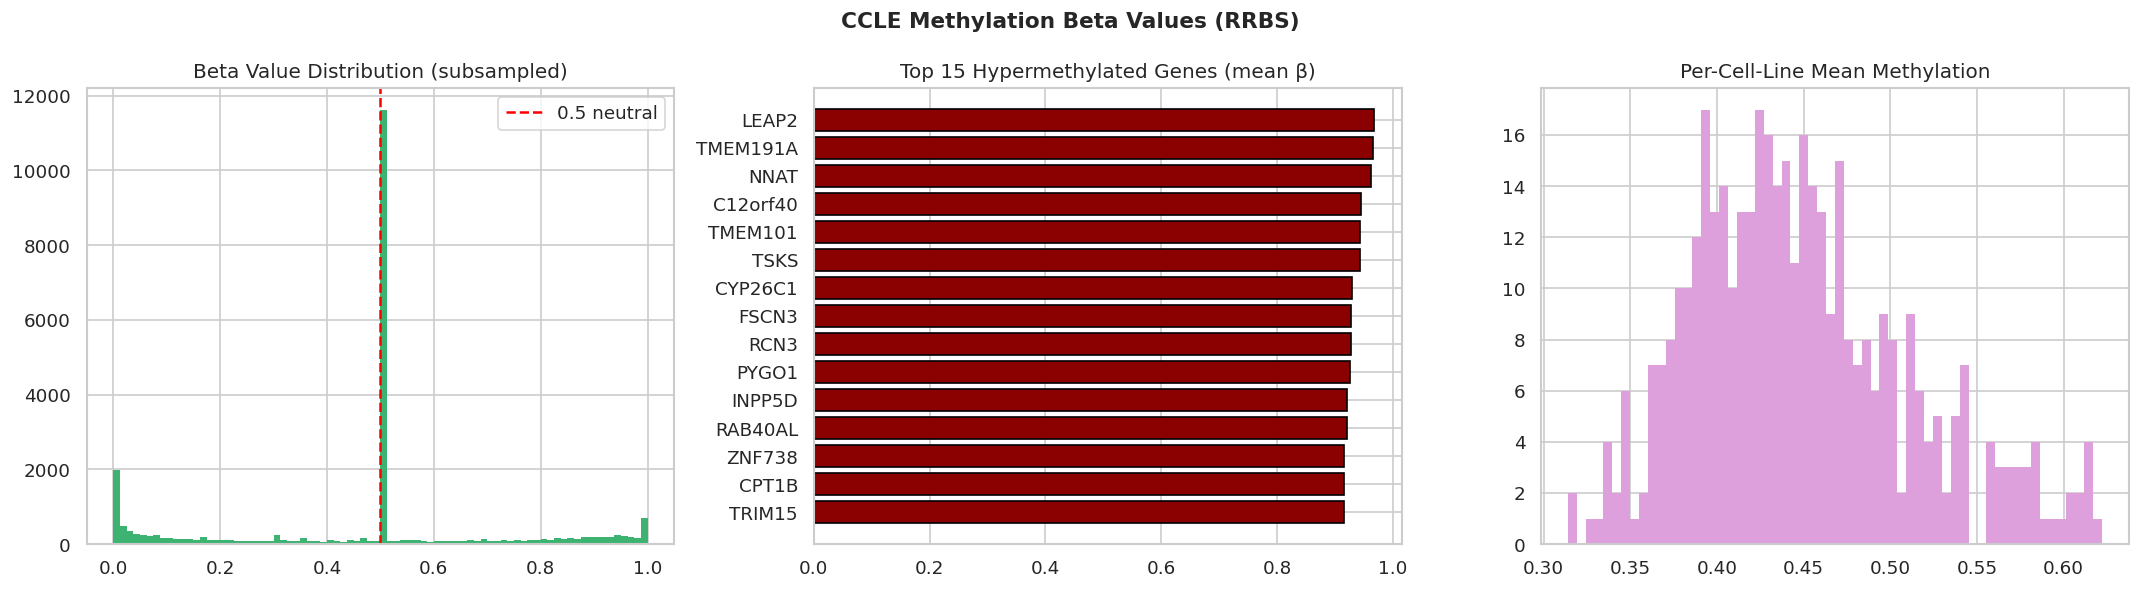

  [Methylation filtered] RAM: 9.9 MB | shape: (411, 6000)
Cell lines with Methylation data: 411


In [11]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 11 — CCLE METHYLATION (RRBS) — ROBUST IMPLEMENTATION
# ═══════════════════════════════════════════════════════════════════════
section('11. CCLE METHYLATION (RRBS) — ROBUST GENE OVERLAP')

print('Loading CCLE_RRBS_TSS_1kb_20180614.txt...')
meth_raw = pd.read_csv(f"{CFG['BASE']}/{CFG['METH_CSV']}", sep='\t', low_memory=False)
print(f'Raw shape: {meth_raw.shape}')
print(f'Column names [0:8]: {meth_raw.columns.tolist()[:8]}')

if 'gene' in meth_raw.columns:
    gene_col_values = meth_raw['gene'].values
    print(f'Gene column found. Sample values: {gene_col_values[:5]}')
else:
    gene_col_values = meth_raw.iloc[:, 0].values
    print(f'Using first column as gene names. Sample: {gene_col_values[:5]}')

meta_cols = ['gene', 'chr', 'fpos', 'tpos', 'strand', 'avg_coverage']
meth_data  = meth_raw.drop(columns=meta_cols, errors='ignore')
print(f'\nAfter dropping metadata: {meth_data.shape}')

meth_data = meth_data.apply(pd.to_numeric, errors='coerce').astype(np.float32)
meth_data.index = gene_col_values

n_tss_before = len(meth_data)
meth_data     = meth_data.groupby(meth_data.index).mean()
print(f'TSS aggregation: {n_tss_before:,} TSS → {len(meth_data):,} unique genes')

meth_data = meth_data.T
print(f'After transpose: {meth_data.shape}')

model_map = pd.read_csv(f"{CFG['BASE']}/{CFG['MODEL_CSV']}", usecols=['ModelID', 'CCLEName'])
model_map = model_map.dropna(subset=['CCLEName'])
ccle_to_model = dict(zip(model_map['CCLEName'], model_map['ModelID']))

n_before_map = len(meth_data)
meth_data.index = meth_data.index.map(lambda x: ccle_to_model.get(x, None))
meth_data = meth_data[meth_data.index.notna()].copy()
meth_data.index = meth_data.index.astype(str)
print(f'Mapped CCLEName → ModelID: {n_before_map:,} → {len(meth_data):,} cell lines')

n_before_filter = len(meth_data)
meth_data = meth_data[meth_data.index.isin(valid_model_ids)].copy()
print(f'Filtered to cell lines with GDSC2 IC50: {n_before_filter:,} → {len(meth_data):,}')

nan_before = meth_data.isnull().sum().sum()
gene_means_fill = meth_data.mean(axis=0)
meth_data = meth_data.fillna(gene_means_fill)
meth_data = meth_data.fillna(0.5)
meth_data = meth_data.clip(0.0, 1.0).astype(np.float32)
nan_after = meth_data.isnull().sum().sum()
print(f'Missing values: {nan_before:,} → {nan_after:,}')

ccle_meth_genes = set(meth_data.columns)
tcga_meth_genes = set(GENES['meth'])
overlap_e       = ccle_meth_genes & tcga_meth_genes
missing_in_ccle = tcga_meth_genes - ccle_meth_genes

print(f'\nGene space alignment (Methylation):')
print(f'  TCGA selected genes:   {len(GENES["meth"]):,}')
print(f'  CCLE RRBS genes:       {len(ccle_meth_genes):,}')
print(f'  Overlap:               {len(overlap_e):,}  ({len(overlap_e)/len(GENES["meth"])*100:.1f}%)')
print(f'  Missing in CCLE→0.5:   {len(missing_in_ccle):,}')

meth_df = meth_data.reindex(columns=GENES['meth'], fill_value=0.5).astype(np.float32)
print(f'\nFinal Methylation shape: {meth_df.shape}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CCLE Methylation Beta Values (RRBS)', fontsize=13, fontweight='bold')
flat_vals = meth_df.values.flatten()[::100]
axes[0].hist(flat_vals, bins=80, color='mediumseagreen', edgecolor='none')
axes[0].set_title('Beta Value Distribution (subsampled)')
axes[0].axvline(0.5, color='red', linestyle='--', label='0.5 neutral')
axes[0].legend()
gene_mean_meth = meth_df.mean(axis=0)
top_hyper = gene_mean_meth.nlargest(15)
axes[1].barh(top_hyper.index, top_hyper.values, color='darkred', edgecolor='black')
axes[1].set_title('Top 15 Hypermethylated Genes (mean β)')
axes[1].invert_yaxis()
sample_mean_meth = meth_df.mean(axis=1)
axes[2].hist(sample_mean_meth, bins=60, color='plum', edgecolor='none')
axes[2].set_title('Per-Cell-Line Mean Methylation')
plt.tight_layout(); plt.show()

valid_model_ids_meth = set(meth_df.index)
mem_usage(meth_df, 'Methylation filtered')
del meth_raw, meth_data, flat_vals, gene_mean_meth, sample_mean_meth
del model_map, ccle_to_model; gc.collect()
print(f'Cell lines with Methylation data: {len(valid_model_ids_meth):,}')


In [12]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 12 — MASTER ALIGNMENT
# ═══════════════════════════════════════════════════════════════════════
section('12. MASTER ALIGNMENT')

print('Cell lines per modality:')
print(f'  mRNA : {len(valid_model_ids_mrna):,}')
print(f'  CNV  : {len(valid_model_ids_cnv):,}')
print(f'  Mut  : {len(valid_model_ids_mut):,}')
print(f'  Meth : {len(valid_model_ids_meth):,}')

have_3    = valid_model_ids_mrna & valid_model_ids_cnv & valid_model_ids_mut
have_all4 = have_3 & valid_model_ids_meth
have_3_no_meth = have_3 - valid_model_ids_meth

print(f'\nAll 4 modalities:        {len(have_all4):,}')
print(f'mRNA+CNV+Mut only:       {len(have_3_no_meth):,}  (methylation will be imputed)')

if len(have_3_no_meth) > 0:
    imp_meth = pd.DataFrame(
        0.5,
        index=sorted(have_3_no_meth),
        columns=GENES['meth'],
        dtype=np.float32
    )
    meth_df = pd.concat([meth_df, imp_meth])
    print(f'Imputed {len(have_3_no_meth)} rows of methylation with 0.5')

common_final = sorted(have_all4 | have_3_no_meth)
print(f'\nFinal usable cell lines: {len(common_final)}')

mrna_df = mrna_df.loc[mrna_df.index.isin(common_final)].reindex(common_final)
cnv_df  = cnv_df.loc[cnv_df.index.isin(common_final)].reindex(common_final)
mut_df  = mut_df.loc[mut_df.index.isin(common_final)].reindex(common_final)
meth_df = meth_df.loc[meth_df.index.isin(common_final)].reindex(common_final)

assert (mrna_df.index == cnv_df.index).all(),  'mRNA/CNV index mismatch!'
assert (mrna_df.index == mut_df.index).all(),  'mRNA/Mut index mismatch!'
assert (mrna_df.index == meth_df.index).all(), 'mRNA/Meth index mismatch!'
print('All modalities aligned ✓')

ic50 = ic50[ic50['ModelID'].isin(common_final)].copy()
print(f'IC50 pairs after alignment: {len(ic50):,}')



══════════════════════════════════════════════════════════════════════
  12. MASTER ALIGNMENT
══════════════════════════════════════════════════════════════════════
Cell lines per modality:
  mRNA : 524
  CNV  : 382
  Mut  : 667
  Meth : 411

All 4 modalities:        306
mRNA+CNV+Mut only:       75  (methylation will be imputed)
Imputed 75 rows of methylation with 0.5

Final usable cell lines: 381
All modalities aligned ✓
IC50 pairs after alignment: 9,343


In [13]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 13 — SCALING
# ═══════════════════════════════════════════════════════════════════════
section('13. SCALING')

import joblib

np.random.seed(CFG['SEED'])
all_cls_arr = np.array(common_final)
cl_cancer_type_map = (ic50.drop_duplicates('ModelID')
                          .set_index('ModelID')['OncotreePrimaryDisease']
                          .to_dict())
types_arr = np.array([cl_cancer_type_map.get(cl, 'Unknown') for cl in all_cls_arr])

type_counts = pd.Series(types_arr).value_counts()
dominant_type = type_counts.index[0]
types_arr = np.where(pd.Series(types_arr).map(type_counts) < 6, dominant_type, types_arr)

le = LabelEncoder()
type_enc = le.fit_transform(types_arr)

sss_scale = StratifiedShuffleSplit(
    n_splits=1,
    test_size=CFG['WARM_VAL_FRAC'] + CFG['WARM_TEST_FRAC'],
    random_state=CFG['SEED']
)
tr_idx_scale, _ = next(sss_scale.split(all_cls_arr, type_enc))
cl_train_for_scaling = set(all_cls_arr[tr_idx_scale])
print(f'Scaling fit on {len(cl_train_for_scaling)} training cell lines.')

def scale_modality(df, train_ids, scaler_type, tag):
    X_tr = df.loc[df.index.isin(train_ids)].values
    if scaler_type == 'standard':
        sc = StandardScaler(); sc.fit(X_tr)
    elif scaler_type == 'maxabs':
        sc = MaxAbsScaler(); sc.fit(X_tr)
    else:
        sc = None
    scaled = sc.transform(df.values) if sc is not None else df.values.copy()
    out = pd.DataFrame(scaled.astype(np.float32), index=df.index, columns=df.columns)
    print(f'  [{tag:<4}] {scaler_type:<10} | train mean={X_tr.mean():.3f} std={X_tr.std():.3f}')
    return out, sc

mrna_scaled, sc_mrna = scale_modality(mrna_df, cl_train_for_scaling, 'standard', 'mRNA')
cnv_scaled,  sc_cnv  = scale_modality(cnv_df,  cl_train_for_scaling, 'maxabs',   'CNV')
mut_scaled,  _       = scale_modality(mut_df,  cl_train_for_scaling, 'none',     'Mut')
meth_scaled, _       = scale_modality(meth_df, cl_train_for_scaling, 'none',     'Meth')

print('\nVerification (mRNA train, should be ≈0 mean, ≈1 std):')
tr_v = mrna_scaled.loc[mrna_scaled.index.isin(cl_train_for_scaling)].values
print(f'  mean={tr_v.mean():.4f}  std={tr_v.std():.4f}')

del mrna_df, cnv_df, mut_df, meth_df; gc.collect()



══════════════════════════════════════════════════════════════════════
  13. SCALING
══════════════════════════════════════════════════════════════════════
Scaling fit on 304 training cell lines.
  [mRNA] standard   | train mean=1.359 std=1.966
  [CNV ] maxabs     | train mean=-0.857 std=0.526
  [Mut ] none       | train mean=0.011 std=0.106
  [Meth] none       | train mean=0.456 std=0.238

Verification (mRNA train, should be ≈0 mean, ≈1 std):
  mean=0.0000  std=0.9594


0

In [14]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 14 — THREE EVALUATION SPLITS
# ═══════════════════════════════════════════════════════════════════════
section('14. GENERATING THREE EVALUATION SPLITS')

from sklearn.model_selection import train_test_split
np.random.seed(CFG['SEED'])

# ── SPLIT 1: TRUE WARM-START ─────────────────────────────────────────────
print('─'*60)
print('SPLIT 1: WARM-START (80/10/10 random pair split)')
print('─'*60)

# True Warm Split: Split the actual pairs, not the cell lines
tv_pairs, ic50_warm_te = train_test_split(ic50, test_size=CFG['WARM_TEST_FRAC'], random_state=CFG['SEED'])
ic50_warm_tr, ic50_warm_vl = train_test_split(tv_pairs, test_size=CFG['WARM_VAL_FRAC'] / (1.0 - CFG['WARM_TEST_FRAC']), random_state=CFG['SEED'])

print(f'  Train pairs: {len(ic50_warm_tr):>6,} ({len(ic50_warm_tr)/len(ic50)*100:.1f}%)')
print(f'  Val pairs:   {len(ic50_warm_vl):>6,} ({len(ic50_warm_vl)/len(ic50)*100:.1f}%)')
print(f'  Test pairs:  {len(ic50_warm_te):>6,} ({len(ic50_warm_te)/len(ic50)*100:.1f}%) ✓')


# ── SPLIT 2: CELL-COLD-START ─────────────────────────────────────────────
print('\n' + '─'*60)
print('SPLIT 2: CELL-COLD-START (20% cell lines held out for test)')
print('─'*60)

all_cls_arr  = np.array(common_final)
types_arr    = np.array([cl_cancer_type_map.get(cl, 'Unknown') for cl in all_cls_arr])
type_counts  = pd.Series(types_arr).value_counts()
dominant_type = type_counts.index[0]

# FIX for the crash: map rare classes (< 6 samples) to the dominant class for splitting
types_arr_safe = np.where(pd.Series(types_arr).map(type_counts) < 6, dominant_type, types_arr)
le = LabelEncoder()
type_enc = le.fit_transform(types_arr_safe)

sss_cell = StratifiedShuffleSplit(n_splits=1, test_size=CFG['CELL_COLD_FRAC'], random_state=CFG['SEED'] + 1)
cell_tr_idx, cell_te_idx = next(sss_cell.split(all_cls_arr, type_enc))

cl_cell_trainval = list(all_cls_arr[cell_tr_idx])
cl_cell_test     = list(all_cls_arr[cell_te_idx])

type_enc_tv = type_enc[cell_tr_idx]
tv_arr      = np.array(cl_cell_trainval)
type_enc_tv_safe = np.where(pd.Series(type_enc_tv).map(pd.Series(type_enc_tv).value_counts()) < 6, 
                            pd.Series(type_enc_tv).value_counts().index[0], type_enc_tv)

sss_cell2 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=CFG['SEED'])
tv_tr_idx, tv_vl_idx = next(sss_cell2.split(tv_arr, type_enc_tv_safe))
cl_cell_train = list(tv_arr[tv_tr_idx])
cl_cell_val   = list(tv_arr[tv_vl_idx])

assert not set(cl_cell_train) & set(cl_cell_test), 'CELL COLD TRAIN/TEST LEAKAGE!'
assert not set(cl_cell_val)   & set(cl_cell_test), 'CELL COLD VAL/TEST LEAKAGE!'

ic50_cc_tr = ic50[ic50['ModelID'].isin(cl_cell_train)].copy()
ic50_cc_vl = ic50[ic50['ModelID'].isin(cl_cell_val)].copy()
ic50_cc_te = ic50[ic50['ModelID'].isin(cl_cell_test)].copy()

print(f'  Train pairs: {len(ic50_cc_tr):>6,}')
print(f'  Val pairs:   {len(ic50_cc_vl):>6,}')
print(f'  Test pairs:  {len(ic50_cc_te):>6,}  (Cells completely unseen) ✓')


# ── SPLIT 3: DRUG-COLD-START ─────────────────────────────────────────────
print('\n' + '─'*60)
print('SPLIT 3: DRUG-COLD-START (15% drugs never seen during training)')
print('─'*60)

drug_arr = np.array(VALID_DRUG_NAMES)
n_cold   = max(1, int(len(drug_arr) * CFG['DRUG_COLD_FRAC']))
rng = np.random.default_rng(CFG['SEED'] + 2)
cold_idx        = rng.choice(len(drug_arr), size=n_cold, replace=False)
warm_idx        = np.setdiff1d(np.arange(len(drug_arr)), cold_idx)

drug_cold_test  = list(drug_arr[cold_idx])
drug_warm_pool  = list(drug_arr[warm_idx])

# Hold out the cold drugs for testing
ic50_dc_te = ic50[ic50['DRUG_NAME'].isin(drug_cold_test)].copy()

# The remaining "warm" drugs are split 90/10 for Train/Val using random pairs
ic50_drug_warm = ic50[ic50['DRUG_NAME'].isin(drug_warm_pool)].copy()
ic50_dc_tr, ic50_dc_vl = train_test_split(ic50_drug_warm, test_size=0.10, random_state=CFG['SEED'])

print(f'  Warm drugs (train+val pool): {len(drug_warm_pool)}')
print(f'  Cold drugs (test only):      {len(drug_cold_test)}')
print(f'  Train pairs: {len(ic50_dc_tr):>6,}')
print(f'  Val pairs:   {len(ic50_dc_vl):>6,}')
print(f'  Test pairs:  {len(ic50_dc_te):>6,}  (Drugs completely unseen) ✓')

print('\n' + '═'*65)
print('  SPLIT SUMMARY READY')
print('═'*65)


══════════════════════════════════════════════════════════════════════
  14. GENERATING THREE EVALUATION SPLITS
══════════════════════════════════════════════════════════════════════
────────────────────────────────────────────────────────────
SPLIT 1: WARM-START (80/10/10 random pair split)
────────────────────────────────────────────────────────────
  Train pairs:  7,473 (80.0%)
  Val pairs:      935 (10.0%)
  Test pairs:     935 (10.0%) ✓

────────────────────────────────────────────────────────────
SPLIT 2: CELL-COLD-START (20% cell lines held out for test)
────────────────────────────────────────────────────────────
  Train pairs:  6,814
  Val pairs:      766
  Test pairs:   1,763  (Cells completely unseen) ✓

────────────────────────────────────────────────────────────
SPLIT 3: DRUG-COLD-START (15% drugs never seen during training)
────────────────────────────────────────────────────────────
  Warm drugs (train+val pool): 50
  Cold drugs (test only):      8
  Train pairs:  7,443

In [15]:
# ═══════════════════════════════════════════════════════════════════════
#  CELL 15 — SAVE ALL OUTPUTS
# ═══════════════════════════════════════════════════════════════════════
section('15. SAVE ALL OUTPUTS')

OUT = CFG['OUT_DIR']

# ── 1. Save Scaled Omics Data ──
mrna_scaled.to_parquet(f'{OUT}ccle_mrna_scaled.parquet')
cnv_scaled.to_parquet(f'{OUT}ccle_cnv_scaled.parquet')
mut_scaled.to_parquet(f'{OUT}ccle_mut_scaled.parquet')
meth_scaled.to_parquet(f'{OUT}ccle_meth_scaled.parquet')
print('Saved: omics parquets (mrna, cnv, mut, meth)')

# ── 2. Save Exact IC50 Pairs for all 3 Splits (CRITICAL FIX) ──
ic50_warm_tr.to_parquet(f'{OUT}split_warm_tr.parquet', index=False)
ic50_warm_vl.to_parquet(f'{OUT}split_warm_vl.parquet', index=False)
ic50_warm_te.to_parquet(f'{OUT}split_warm_te.parquet', index=False)

ic50_cc_tr.to_parquet(f'{OUT}split_cc_tr.parquet', index=False)
ic50_cc_vl.to_parquet(f'{OUT}split_cc_vl.parquet', index=False)
ic50_cc_te.to_parquet(f'{OUT}split_cc_te.parquet', index=False)

ic50_dc_tr.to_parquet(f'{OUT}split_dc_tr.parquet', index=False)
ic50_dc_vl.to_parquet(f'{OUT}split_dc_vl.parquet', index=False)
ic50_dc_te.to_parquet(f'{OUT}split_dc_te.parquet', index=False)
print('Saved: 9 IC50 Split Parquet files (Warm, Cell-Cold, Drug-Cold)')

# ── 3. Save Drug Metadata ──
smiles_json = {d: smiles_map[d] for d in VALID_DRUG_NAMES}
with open(f'{OUT}drug_smiles.json', 'w') as f:
    json.dump(smiles_json, f, indent=2)
print('Saved: drug_smiles.json')

pd.Series(VALID_DRUG_NAMES).to_csv(f'{OUT}valid_drug_names.csv', index=False, header=False)
print('Saved: valid_drug_names.csv')

with open(f'{OUT}drug2idx.json', 'w') as f:
    json.dump(drug2idx, f)
print('Saved: drug2idx.json')

# ── 4. Save Scalers ──
import joblib
joblib.dump(sc_mrna, f'{OUT}scaler_mrna.pkl')
joblib.dump(sc_cnv,  f'{OUT}scaler_cnv.pkl')
print('Saved: scaler_mrna.pkl, scaler_cnv.pkl')

# ── 5. Final Summary ──
print('\n' + '═'*65)
print('  FINAL DATASET SUMMARY — OncoBridge Data Processing v4')
print('═'*65)
print(f'  Dataset:              GDSC2 only')
print(f'  Total cell lines:     {len(common_final)}')
print(f'  Total drugs:          {len(VALID_DRUG_NAMES)}')
print(f'  Total IC50 pairs:     {len(ic50):,}')
print(f'  Drug representation:  Raw canonical SMILES (→ ChemBERTa)')
print(f'  mRNA features:        {mrna_scaled.shape[1]:,}')
print(f'  CNV  features:        {cnv_scaled.shape[1]:,}')
print(f'  Mut  features:        {mut_scaled.shape[1]:,}')
print(f'  Meth features:        {meth_scaled.shape[1]:,}')
print(f'  Methylation overlap:  {len(overlap_e):,}/{len(GENES["meth"])} TCGA genes ({len(overlap_e)/len(GENES["meth"])*100:.1f}%)')
print(f'')
print(f'  WARM-START:       Train {len(ic50_warm_tr):>6,} | Val {len(ic50_warm_vl):>5,} | Test {len(ic50_warm_te):>5,}')
print(f'  CELL-COLD-START:  Train {len(ic50_cc_tr):>6,} | Val {len(ic50_cc_vl):>5,} | Test {len(ic50_cc_te):>5,}')
print(f'  DRUG-COLD-START:  Train {len(ic50_dc_tr):>6,} | Val {len(ic50_dc_vl):>5,} | Test {len(ic50_dc_te):>5,}')
print('═'*65)
print('Data processing complete. Ready for Notebook 2 (Architecture & Training).')


══════════════════════════════════════════════════════════════════════
  15. SAVE ALL OUTPUTS
══════════════════════════════════════════════════════════════════════
Saved: omics parquets (mrna, cnv, mut, meth)
Saved: 9 IC50 Split Parquet files (Warm, Cell-Cold, Drug-Cold)
Saved: drug_smiles.json
Saved: valid_drug_names.csv
Saved: drug2idx.json
Saved: scaler_mrna.pkl, scaler_cnv.pkl

═════════════════════════════════════════════════════════════════
  FINAL DATASET SUMMARY — OncoBridge Data Processing v4
═════════════════════════════════════════════════════════════════
  Dataset:              GDSC2 only
  Total cell lines:     381
  Total drugs:          58
  Total IC50 pairs:     9,343
  Drug representation:  Raw canonical SMILES (→ ChemBERTa)
  mRNA features:        8,011
  CNV  features:        3,500
  Mut  features:        2,500
  Meth features:        6,000
  Methylation overlap:  3,205/6000 TCGA genes (53.4%)

  WARM-START:       Train  7,473 | Val   935 | Test   935
  CELL-COLD-S